### 07 — Project 1 Hyperparameter Tuning

### Intelligent CFPB Product Classification

### Objective

- Tune the frozen Product Classification pipeline using the training and
validation datasets.

### Frozen design

- Target: `Product`
- Prediction event: `Date received`
- Features:
  - Consumer complaint narrative
  - Company
- Representation:
  - Word TF-IDF
  - Character TF-IDF
- Model:
  - Logistic Regression
- Primary metric:
  - Macro F1

### Tuning strategy

- 1. Establish reproducible baseline
- 2. Tune Logistic Regression `C`
- 3. Test class weighting
- 4. Optionally test limited TF-IDF regularization
- 5. Compare experiments
- 6. Select the simplest strong configuration
- 7. Freeze final candidate

### Important rule

- The test set remains completely untouched in this notebook.

### Basic Imports

In [1]:
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.sparse import hstack, csr_matrix

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
## project Paths
PROJECT_ROOT = Path("..")

TRAIN_PATH = PROJECT_ROOT / "Data" / "processed" / "project1_train.csv"
VAL_PATH = PROJECT_ROOT / "Data" / "processed" / "project1_validation.csv"

REPORT_DIR = PROJECT_ROOT / "Reports" / "project1"

REPORT_DIR.mkdir(parents=True, exist_ok=True)

print("Train:", TRAIN_PATH)
print("Validation:", VAL_PATH)
print("Report directory:", REPORT_DIR)

Train: ..\Data\processed\project1_train.csv
Validation: ..\Data\processed\project1_validation.csv
Report directory: ..\Reports\project1


In [ ]:
## Load train and validation data
train_df = pd.read_csv(TRAIN_PATH)
val_df = pd.read_csv(VAL_PATH)

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)

Train shape: (58422, 18)
Validation shape: (11685, 18)


In [4]:
## Validate required columns
REQUIRED_COLUMNS = [
    "Consumer complaint narrative",
    "Company",
    "Product",
]

missing_train = [
    col for col in REQUIRED_COLUMNS
    if col not in train_df.columns
]

missing_val = [
    col for col in REQUIRED_COLUMNS
    if col not in val_df.columns
]

assert not missing_train, f"Missing train columns: {missing_train}"
assert not missing_val, f"Missing validation columns: {missing_val}"

print("Required columns: PASS")

Required columns: PASS


### Prepare text and metadata

In [5]:
TEXT_COL = "Consumer complaint narrative"
COMPANY_COL = "Company"
TARGET_COL = "Product"

X_train_text = train_df[TEXT_COL].fillna("").astype(str)
X_val_text = val_df[TEXT_COL].fillna("").astype(str)

X_train_company = train_df[[COMPANY_COL]].fillna("MISSING").astype(str)
X_val_company = val_df[[COMPANY_COL]].fillna("MISSING").astype(str)

y_train = train_df[TARGET_COL].astype(str)
y_val = val_df[TARGET_COL].astype(str)

print("Training rows:", len(y_train))
print("Validation rows:", len(y_val))
print("Number of classes:", y_train.nunique())

Training rows: 58422
Validation rows: 11685
Number of classes: 11


In [6]:
## Verify target alignment
train_classes = set(y_train.unique())
val_classes = set(y_val.unique())

print("Train classes:", len(train_classes))
print("Validation classes:", len(val_classes))

assert train_classes == val_classes, (
    "Train and validation class sets do not match."
)

print("Target class alignment: PASS")

Train classes: 11
Validation classes: 11
Target class alignment: PASS


### Build the frozen feature representation
- Fit vectorizers and encoder only on training data.

In [7]:
word_vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_features=10000,
    sublinear_tf=True,
)

char_vectorizer = TfidfVectorizer(
    analyzer="char",
    ngram_range=(3, 5),
    min_df=2,
    max_features=10000,
    sublinear_tf=True,
)

company_encoder = OneHotEncoder(
    handle_unknown="ignore",
)

X_train_word = word_vectorizer.fit_transform(X_train_text)
X_val_word = word_vectorizer.transform(X_val_text)

X_train_char = char_vectorizer.fit_transform(X_train_text)
X_val_char = char_vectorizer.transform(X_val_text)

X_train_company_encoded = company_encoder.fit_transform(X_train_company)
X_val_company_encoded = company_encoder.transform(X_val_company)

X_train = hstack([
    X_train_word,
    X_train_char,
    X_train_company_encoded,
]).tocsr()

X_val = hstack([
    X_val_word,
    X_val_char,
    X_val_company_encoded,
]).tocsr()

print("Word features:", X_train_word.shape)
print("Character features:", X_train_char.shape)
print("Company features:", X_train_company_encoded.shape)
print("Combined train:", X_train.shape)
print("Combined validation:", X_val.shape)

Word features: (58422, 10000)
Character features: (58422, 10000)
Company features: (58422, 1751)
Combined train: (58422, 21751)
Combined validation: (11685, 21751)


In [8]:
### Feature-space sanity check
assert X_train.shape[1] == X_val.shape[1]

assert X_train.shape[0] == len(y_train)
assert X_val.shape[0] == len(y_val)

print("Feature-space alignment: PASS")

Feature-space alignment: PASS


In [9]:
## Evaluation helper
def evaluate_model(model, X, y, split_name="validation"):
    predictions = model.predict(X)

    return {
        "split": split_name,
        "accuracy": accuracy_score(y, predictions),
        "macro_f1": f1_score(y, predictions, average="macro"),
        "weighted_f1": f1_score(y, predictions, average="weighted"),
    }

In [12]:
### Experiment helper
results = []


def run_experiment(
    experiment_name,
    C=1.0,
    class_weight=None,
):
    model = LogisticRegression(
        C=C,
        class_weight=class_weight,
        max_iter=2000,
        solver="lbfgs",
        random_state=RANDOM_STATE,
    )

    model.fit(X_train, y_train)

    metrics = evaluate_model(
        model,
        X_val,
        y_val,
        split_name="validation",
    )

    metrics["experiment"] = experiment_name
    metrics["C"] = C
    metrics["class_weight"] = str(class_weight)

    results.append(metrics)

    return model

In [13]:
## Reproducible baseline
baseline_model = run_experiment(
    experiment_name="Baseline_C1",
    C=1.0,
    class_weight=None,
)

baseline_metrics = results[-1]

baseline_metrics

{'split': 'validation',
 'accuracy': 0.8680359435173299,
 'macro_f1': 0.8043225938731792,
 'weighted_f1': 0.8660806060462446,
 'experiment': 'Baseline_C1',
 'C': 1.0,
 'class_weight': 'None'}

## Baseline interpretation

This baseline is the control experiment.

Every later experiment must be compared against this configuration.

The question is not:

> "Did the score become higher?"

The stronger question is:

> "Did the model improve in a meaningful way, especially on minority
> Product classes, without introducing unnecessary complexity?"

Primary metric:
- Macro F1

Secondary metrics:
- Accuracy
- Weighted F1

### Tune Logistic Regression C
- Why tune C?
- C controls the strength of regularization.
Smaller C
    ↓
Stronger regularization
    ↓
Simpler model

Larger C
    ↓
Weaker regularization
    ↓
More freedom to fit training patterns

In [14]:
C_values = [
    0.1,
    0.25,
    0.5,
    1.0,
    2.0,
    4.0,
]

C_models = {}

for C in C_values:
    model = run_experiment(
        experiment_name=f"C_{C}",
        C=C,
        class_weight=None,
    )

    C_models[C] = model

print("C tuning complete.")

C tuning complete.


In [15]:
### Compare C experiments
results_df = pd.DataFrame(results)

results_df.sort_values(
    by="macro_f1",
    ascending=False
)

,split,accuracy,macro_f1,weighted_f1,experiment,C,class_weight
0,validation,0.868036,0.804323,0.866081,Baseline_C1,1.00,None
4,validation,0.868036,0.804323,0.866081,C_1.0,1.00,None
5,validation,0.866410,0.803721,0.864537,C_2.0,2.00,None
6,validation,0.862901,0.801850,0.861197,C_4.0,4.00,None
3,validation,0.866752,0.798950,0.864668,C_0.5,0.50,None
2,validation,0.864442,0.787126,0.861684,C_0.25,0.25,None
1,validation,0.855028,0.761545,0.851108,C_0.1,0.10,None


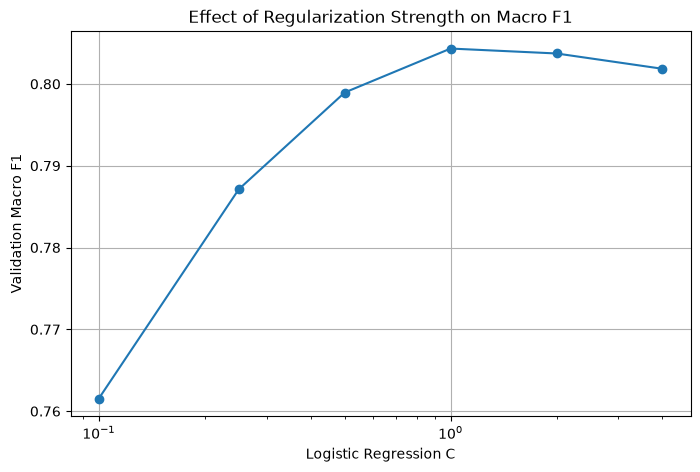

In [16]:
## Visualize C vs Macro F1
c_results = results_df[
    results_df["experiment"].str.startswith("C_")
].copy()

c_results = c_results.sort_values("C")

plt.figure(figsize=(8, 5))

plt.plot(
    c_results["C"],
    c_results["macro_f1"],
    marker="o",
)

plt.xscale("log")
plt.xlabel("Logistic Regression C")
plt.ylabel("Validation Macro F1")
plt.title("Effect of Regularization Strength on Macro F1")
plt.grid(True)

plt.show()

In [17]:
## Find best C
best_c_row = c_results.loc[
    c_results["macro_f1"].idxmax()
]

best_C = float(best_c_row["C"])

print("Best C:", best_C)
print("Macro F1:", best_c_row["macro_f1"])
print("Accuracy:", best_c_row["accuracy"])
print("Weighted F1:", best_c_row["weighted_f1"])

Best C: 1.0
Macro F1: 0.8043225938731792
Accuracy: 0.8680359435173299
Weighted F1: 0.8660806060462446


In [18]:
### Analyze whether C actually matters
c_results[
    [
        "C",
        "accuracy",
        "macro_f1",
        "weighted_f1",
    ]
].sort_values("C")

,C,accuracy,macro_f1,weighted_f1
1,0.10,0.855028,0.761545,0.851108
2,0.25,0.864442,0.787126,0.861684
3,0.50,0.866752,0.798950,0.864668
4,1.00,0.868036,0.804323,0.866081
5,2.00,0.866410,0.803721,0.864537
6,4.00,0.862901,0.801850,0.861197


### Class-weight experiment
- investigate whether the imbalance is limiting minority-class performance.
- Test:
    - None
    - balanced

In [19]:
class_weight_options = [
    None,
    "balanced",
]

for weight in class_weight_options:
    if weight is None:
        experiment_name = f"ClassWeight_none_C{best_C}"
    else:
        experiment_name = f"ClassWeight_{weight}_C{best_C}"

    run_experiment(
        experiment_name=experiment_name,
        C=best_C,
        class_weight=weight,
    )

print("Class-weight experiments complete.")

Class-weight experiments complete.


In [20]:
## Compare class weighting
class_weight_results = results_df[
    results_df["experiment"].str.contains("ClassWeight")
].copy()

class_weight_results[
    [
        "experiment",
        "accuracy",
        "macro_f1",
        "weighted_f1",
    ]
].sort_values(
    by="macro_f1",
    ascending=False
)

,experiment,accuracy,macro_f1,weighted_f1


### Class Weight Interpretation

- `class_weight="balanced"` gives relatively more importance to minority
classes during training.

- But higher minority-class recall does NOT automatically mean a better model.

- We must check:

- Macro F1
- Per-class recall
- Per-class precision
- Confusion matrix

- A good outcome would be:

   - minority recall ↑
   - while
   - majority-class performance does not collapse.

- If Macro F1 decreases substantially, class weighting should not be adopted
just because it "helps imbalance."

In [21]:
### Select current candidate

tuning_results = pd.DataFrame(results)

best_row = tuning_results.loc[
    tuning_results["macro_f1"].idxmax()
]

best_C = float(best_row["C"])

best_class_weight = (
    None
    if best_row["class_weight"] == "None"
    else best_row["class_weight"]
)

print("Current best experiment:")
print(best_row)

Current best experiment:
split            validation
accuracy           0.868036
macro_f1           0.804323
weighted_f1        0.866081
experiment      Baseline_C1
C                       1.0
class_weight           None
Name: 0, dtype: object


In [23]:
### Train current best model

best_model = LogisticRegression(
    C=best_C,
    class_weight=best_class_weight,
    max_iter=2000,
    solver="lbfgs",
    random_state=RANDOM_STATE,
)

best_model.fit(X_train, y_train)

print("Best candidate model trained.")

Best candidate model trained.


In [24]:
### Detailed validation report

val_predictions = best_model.predict(X_val)

print(
    classification_report(
        y_val,
        val_predictions,
        digits=4,
        zero_division=0,
    )
)

                                                         precision    recall  f1-score   support

                            Checking or savings account     0.7968    0.8683    0.8311      2096
                                            Credit card     0.8552    0.8665    0.8608      1970
    Credit reporting or other personal consumer reports     0.8274    0.8742    0.8502       477
                                        Debt collection     0.9270    0.9366    0.9317      3848
                              Debt or credit management     0.9250    0.3592    0.5175       103
     Money transfer, virtual currency, or money service     0.7707    0.6973    0.7322       935
                                               Mortgage     0.9524    0.9449    0.9486       762
Payday loan, title loan, personal loan, or advance loan     0.7486    0.6578    0.7003       412
                                           Prepaid card     0.8090    0.5538    0.6575       130
                             

In [25]:
### Per-class F1 comparison with baseline
baseline_predictions = baseline_model.predict(X_val)

In [26]:
baseline_report = classification_report(
    y_val,
    baseline_predictions,
    output_dict=True,
    zero_division=0,
)

best_report = classification_report(
    y_val,
    val_predictions,
    output_dict=True,
    zero_division=0,
)

class_comparison = []

for class_name in sorted(train_classes):
    class_comparison.append({
        "Product": class_name,
        "Baseline_F1": baseline_report[class_name]["f1-score"],
        "Tuned_F1": best_report[class_name]["f1-score"],
        "F1_Change": (
            best_report[class_name]["f1-score"]
            - baseline_report[class_name]["f1-score"]
        ),
        "Baseline_Recall": baseline_report[class_name]["recall"],
        "Tuned_Recall": best_report[class_name]["recall"],
    })

class_comparison_df = pd.DataFrame(class_comparison)

class_comparison_df.sort_values(
    by="F1_Change"
)

,Product,Baseline_F1,Tuned_F1,F1_Change,Baseline_Recall,Tuned_Recall
0,Checking or savings account,0.831050,0.831050,0.0,0.868321,0.868321
1,Credit card,0.860817,0.860817,0.0,0.866497,0.866497
2,Credit reporting or other personal consumer re...,0.850153,0.850153,0.0,0.874214,0.874214
3,Debt collection,0.931748,0.931748,0.0,0.936590,0.936590
4,Debt or credit management,0.517483,0.517483,0.0,0.359223,0.359223
5,"Money transfer, virtual currency, or money ser...",0.732173,0.732173,0.0,0.697326,0.697326
6,Mortgage,0.948617,0.948617,0.0,0.944882,0.944882
7,"Payday loan, title loan, personal loan, or adv...",0.700258,0.700258,0.0,0.657767,0.657767
8,Prepaid card,0.657534,0.657534,0.0,0.553846,0.553846
9,Student loan,0.954368,0.954368,0.0,0.953125,0.953125


In [27]:
## Identify classes that improved / degraded
print("Largest F1 improvements:")
display(
    class_comparison_df.sort_values(
        "F1_Change",
        ascending=False
    ).head(5)
)

print("\nLargest F1 declines:")
display(
    class_comparison_df.sort_values(
        "F1_Change"
    ).head(5)
)

Largest F1 improvements:


,Product,Baseline_F1,Tuned_F1,F1_Change,Baseline_Recall,Tuned_Recall
0,Checking or savings account,0.831050,0.831050,0.0,0.868321,0.868321
1,Credit card,0.860817,0.860817,0.0,0.866497,0.866497
2,Credit reporting or other personal consumer re...,0.850153,0.850153,0.0,0.874214,0.874214
3,Debt collection,0.931748,0.931748,0.0,0.936590,0.936590
4,Debt or credit management,0.517483,0.517483,0.0,0.359223,0.359223



Largest F1 declines:


,Product,Baseline_F1,Tuned_F1,F1_Change,Baseline_Recall,Tuned_Recall
0,Checking or savings account,0.831050,0.831050,0.0,0.868321,0.868321
1,Credit card,0.860817,0.860817,0.0,0.866497,0.866497
2,Credit reporting or other personal consumer re...,0.850153,0.850153,0.0,0.874214,0.874214
3,Debt collection,0.931748,0.931748,0.0,0.936590,0.936590
4,Debt or credit management,0.517483,0.517483,0.0,0.359223,0.359223


### Confusion Matrix

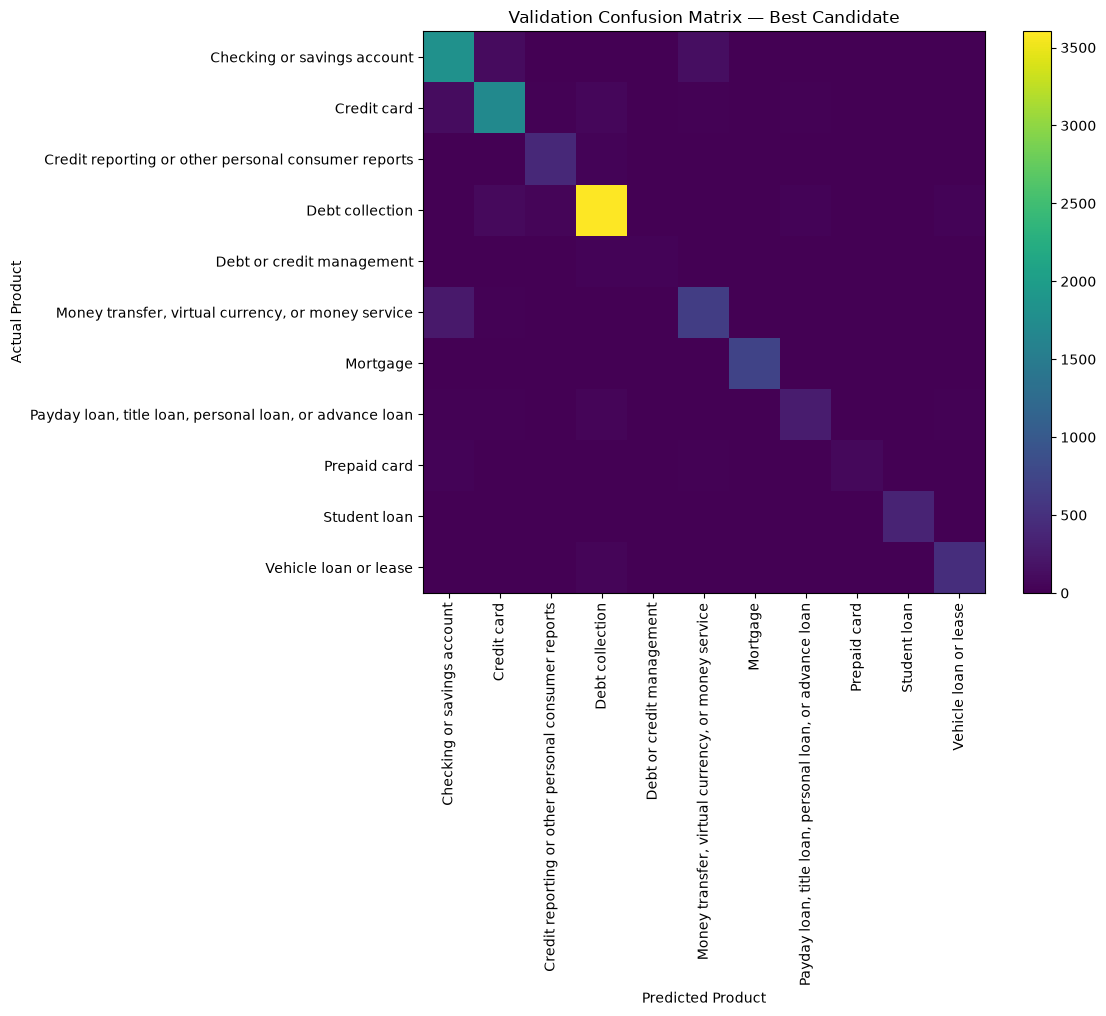

In [28]:
labels = sorted(train_classes)

cm = confusion_matrix(
    y_val,
    val_predictions,
    labels=labels,
)

plt.figure(figsize=(12, 10))

plt.imshow(cm)

plt.xticks(
    range(len(labels)),
    labels,
    rotation=90,
)

plt.yticks(
    range(len(labels)),
    labels,
)

plt.xlabel("Predicted Product")
plt.ylabel("Actual Product")
plt.title("Validation Confusion Matrix — Best Candidate")

plt.colorbar()

plt.tight_layout()
plt.show()

### Top confusion pairs

- The raw confusion matrix is useful, but a ranked list is easier to analyze.

In [29]:
confusion_pairs = []

for i, actual in enumerate(labels):
    for j, predicted in enumerate(labels):
        if i != j and cm[i, j] > 0:
            confusion_pairs.append({
                "Actual": actual,
                "Predicted": predicted,
                "Count": cm[i, j],
            })

confusion_pairs_df = pd.DataFrame(confusion_pairs)

confusion_pairs_df.sort_values(
    "Count",
    ascending=False
).head(15)

,Actual,Predicted,Count
41,"Money transfer, virtual currency, or money ser...",Checking or savings account,242
3,Checking or savings account,"Money transfer, virtual currency, or money ser...",132
8,Credit card,Checking or savings account,124
0,Checking or savings account,Credit card,104
25,Debt collection,Credit card,92
10,Credit card,Debt collection,65
57,"Payday loan, title loan, personal loan, or adv...",Debt collection,56
26,Debt collection,Credit reporting or other personal consumer re...,51
76,Vehicle loan or lease,Debt collection,46
19,Credit reporting or other personal consumer re...,Debt collection,42


### Check model confidence

- Because Logistic Regression provides probabilities, inspect whether errors are highly uncertain.

In [30]:
val_probabilities = best_model.predict_proba(X_val)

max_confidence = val_probabilities.max(axis=1)

confidence_summary = pd.Series(max_confidence).describe()

confidence_summary

count    11685.000000
mean         0.850014
std          0.176739
min          0.198108
25%          0.760446
50%          0.932350
75%          0.987466
max          0.999892
dtype: float64

### Confidence Distribution
- useful later for an operational routing / human-review threshold.

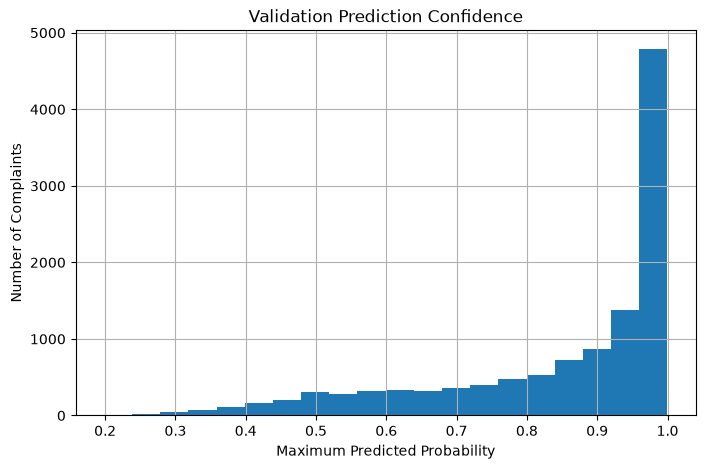

In [31]:
plt.figure(figsize=(8, 5))

plt.hist(
    max_confidence,
    bins=20,
)

plt.xlabel("Maximum Predicted Probability")
plt.ylabel("Number of Complaints")
plt.title("Validation Prediction Confidence")

plt.grid(True)

plt.show()

### Compare All Experiments

In [32]:
final_results = pd.DataFrame(results)

final_results = final_results[
    [
        "experiment",
        "C",
        "class_weight",
        "accuracy",
        "macro_f1",
        "weighted_f1",
    ]
].sort_values(
    by="macro_f1",
    ascending=False,
)

final_results

,experiment,C,class_weight,accuracy,macro_f1,weighted_f1
0,Baseline_C1,1.00,None,0.868036,0.804323,0.866081
4,C_1.0,1.00,None,0.868036,0.804323,0.866081
7,ClassWeight_none_C1.0,1.00,None,0.868036,0.804323,0.866081
5,C_2.0,2.00,None,0.866410,0.803721,0.864537
6,C_4.0,4.00,None,0.862901,0.801850,0.861197
3,C_0.5,0.50,None,0.866752,0.798950,0.864668
2,C_0.25,0.25,None,0.864442,0.787126,0.861684
8,ClassWeight_balanced_C1.0,1.00,balanced,0.852289,0.782962,0.855757
1,C_0.1,0.10,None,0.855028,0.761545,0.851108


In [33]:
### Improvement over baseline
baseline_macro_f1 = results_df.loc[
    results_df["experiment"] == "Baseline_C1",
    "macro_f1"
].iloc[0]

final_results["macro_f1_change_vs_baseline"] = (
    final_results["macro_f1"] - baseline_macro_f1
)

final_results

,experiment,C,class_weight,accuracy,macro_f1,weighted_f1,macro_f1_change_vs_baseline
0,Baseline_C1,1.00,None,0.868036,0.804323,0.866081,0.000000
4,C_1.0,1.00,None,0.868036,0.804323,0.866081,0.000000
7,ClassWeight_none_C1.0,1.00,None,0.868036,0.804323,0.866081,0.000000
5,C_2.0,2.00,None,0.866410,0.803721,0.864537,-0.000602
6,C_4.0,4.00,None,0.862901,0.801850,0.861197,-0.002472
3,C_0.5,0.50,None,0.866752,0.798950,0.864668,-0.005373
2,C_0.25,0.25,None,0.864442,0.787126,0.861684,-0.017197
8,ClassWeight_balanced_C1.0,1.00,balanced,0.852289,0.782962,0.855757,-0.021361
1,C_0.1,0.10,None,0.855028,0.761545,0.851108,-0.042778


### Select final tuning candidate

- Use a small practical tolerance rather than blindly choosing the highest decimal.

In [34]:
best_macro_f1 = final_results["macro_f1"].max()

near_best = final_results[
    final_results["macro_f1"] >= best_macro_f1 - 0.002
].copy()

near_best

,experiment,C,class_weight,accuracy,macro_f1,weighted_f1,macro_f1_change_vs_baseline
0,Baseline_C1,1.0,None,0.868036,0.804323,0.866081,0.000000
4,C_1.0,1.0,None,0.868036,0.804323,0.866081,0.000000
7,ClassWeight_none_C1.0,1.0,None,0.868036,0.804323,0.866081,0.000000
5,C_2.0,2.0,None,0.866410,0.803721,0.864537,-0.000602


#### Hyperparameter Decision Gate

- Select the final candidate using this priority:

- 1. Higher validation Macro F1
- 2. Better minority-class performance
- 3. No major degradation in majority-class performance
- 4. Stable performance rather than a tiny numerical gain
- 5. Simpler configuration when performance is effectively tied

- Do NOT select a model merely because:

- Accuracy is higher
- Weighted F1 is higher
- It has a larger C
- It uses class weighting
- It looks more sophisticated

In [35]:
### Final candidate summary
best_final = final_results.iloc[0]

print("======================================")
print("FINAL TUNING CANDIDATE")
print("======================================")

print(f"Experiment      : {best_final['experiment']}")
print(f"C               : {best_final['C']}")
print(f"Class Weight    : {best_final['class_weight']}")
print(f"Accuracy        : {best_final['accuracy']:.4f}")
print(f"Macro F1        : {best_final['macro_f1']:.4f}")
print(f"Weighted F1     : {best_final['weighted_f1']:.4f}")
print(
    f"Macro F1 Change : "
    f"{best_final['macro_f1_change_vs_baseline']:+.4f}"
)

FINAL TUNING CANDIDATE
Experiment      : Baseline_C1
C               : 1.0
Class Weight    : None
Accuracy        : 0.8680
Macro F1        : 0.8043
Weighted F1     : 0.8661
Macro F1 Change : +0.0000
